# RUL & SOH Prediction

In [ ]:
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load and filter only B0005, B0006, B0007
df = pd.read_csv('/content/engineered_metadata (5).csv')
df = df[df['battery_id'].isin(['B0005', 'B0006', 'B0007','B0018'])].copy()
df.sort_values(by=['battery_id', 'uid'], inplace=True)

# Add cycle count per battery
df['cycle'] = df.groupby('battery_id').cumcount()

# Ensure capacity is numeric
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')
df.dropna(subset=['Capacity'], inplace=True)

# Compute initial capacity C0 and SoH
df['C0'] = df.groupby('battery_id')['Capacity'].transform('first')
df['SoH'] = df['Capacity'] / df['C0']


#  non-trimmed data

In [ ]:
df['SoH_smooth'] = df.groupby('battery_id')['SoH'].transform(
    lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) >= 11 else x
)


In [ ]:
import numpy as np

# Set the sequence length
SEQ_LEN = 16

# Step 2: Create sequences for SoH prediction
def create_soh_sequences(df, feature_col='SoH_smooth', seq_len=SEQ_LEN):
    X, y = [], []
    for batt in df['battery_id'].unique():
        batt_df = df[df['battery_id'] == batt].reset_index(drop=True)
        soh_series = batt_df[feature_col].values
        for i in range(len(soh_series) - seq_len):
            seq_x = soh_series[i:i+seq_len]
            target_y = soh_series[i+seq_len]  # Predict next step
            X.append(seq_x)
            y.append(target_y)
    return np.array(X), np.array(y)

# Apply function
X_soh, y_soh = create_soh_sequences(df)

# Show shape and preview
X_soh.shape, y_soh.shape, X_soh[0], y_soh[0]


((572, 16),
 (572,),
 array([0.99755022, 0.99479193, 0.99232403, 0.9901465 , 0.98825936,
        0.98666259, 0.98637574, 0.98560669, 0.98393205, 0.98256772,
        0.98064058, 0.97862572, 0.97686557, 0.97478239, 0.97094349,
        0.97013367]),
 np.float64(0.9726273333980364))

In [ ]:
# Step 1: Create dictionary of sequences by battery
battery_sequences = {}
SEQ_LEN = 16

for batt in df['battery_id'].unique():
    batt_df = df[df['battery_id'] == batt].reset_index(drop=True)
    soh_series = batt_df['SoH_smooth'].values
    X, y = [], []
    for i in range(len(soh_series) - SEQ_LEN):
        X.append(soh_series[i:i+SEQ_LEN])
        y.append(soh_series[i+SEQ_LEN])
    battery_sequences[batt] = (np.array(X), np.array(y))

# Step 2: Leave-one-battery-out CV
results = []

for test_batt in battery_sequences:
    # Prepare training and testing sets
    X_train, y_train = [], []
    for batt in battery_sequences:
        if batt != test_batt:
            Xb, yb = battery_sequences[batt]
            X_train.append(Xb)
            y_train.append(yb)
    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)

    X_test, y_test = battery_sequences[test_batt]

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=500, max_depth=20, random_state=42)

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append((test_batt, mae, rmse, r2))

results


[('B0005', 0.003024064453003363, 2.0959809622813822e-05, 0.9977566070579998),
 ('B0006', 0.029988184660787173, 0.002278621104119164, 0.8054006310781527),
 ('B0007', 0.0035702089103001014, 2.1534673564042213e-05, 0.996552182503474),
 ('B0018', 0.00440452801253036, 3.764080570364872e-05, 0.9920704220002999)]

B0005 and B0007 are predicted extremely well

B0006 is harder to generalize to, likely due to slight differences in its degradation pattern or sampling rate

# Trims 0.7, 0.8, 0.85


=== Threshold 0.70 ===


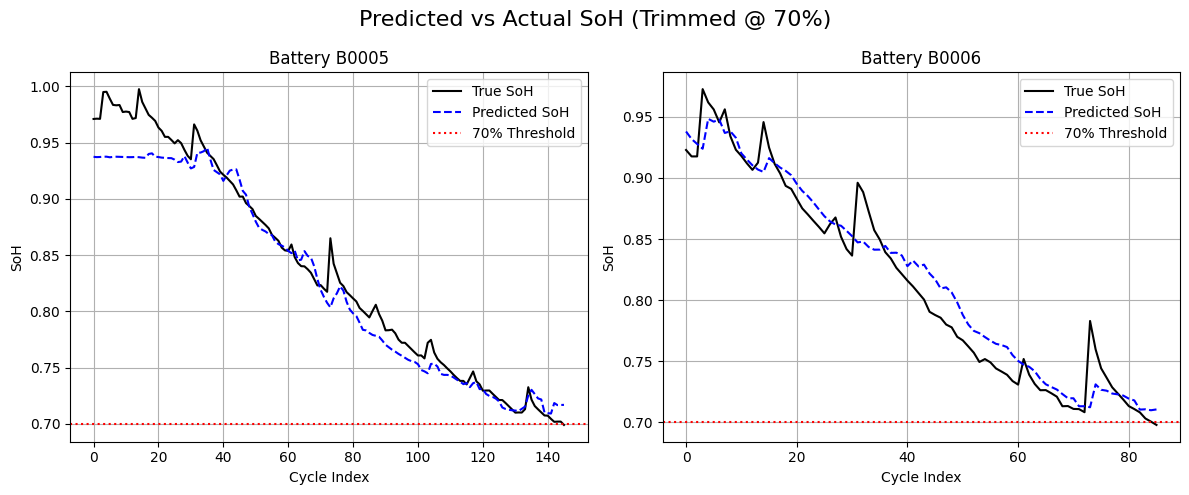

Battery B0005: MAE=0.0144, RMSE=0.0004, R2=0.9551
Battery B0006: MAE=0.0150, RMSE=0.0004, R2=0.9448

=== Threshold 0.80 ===


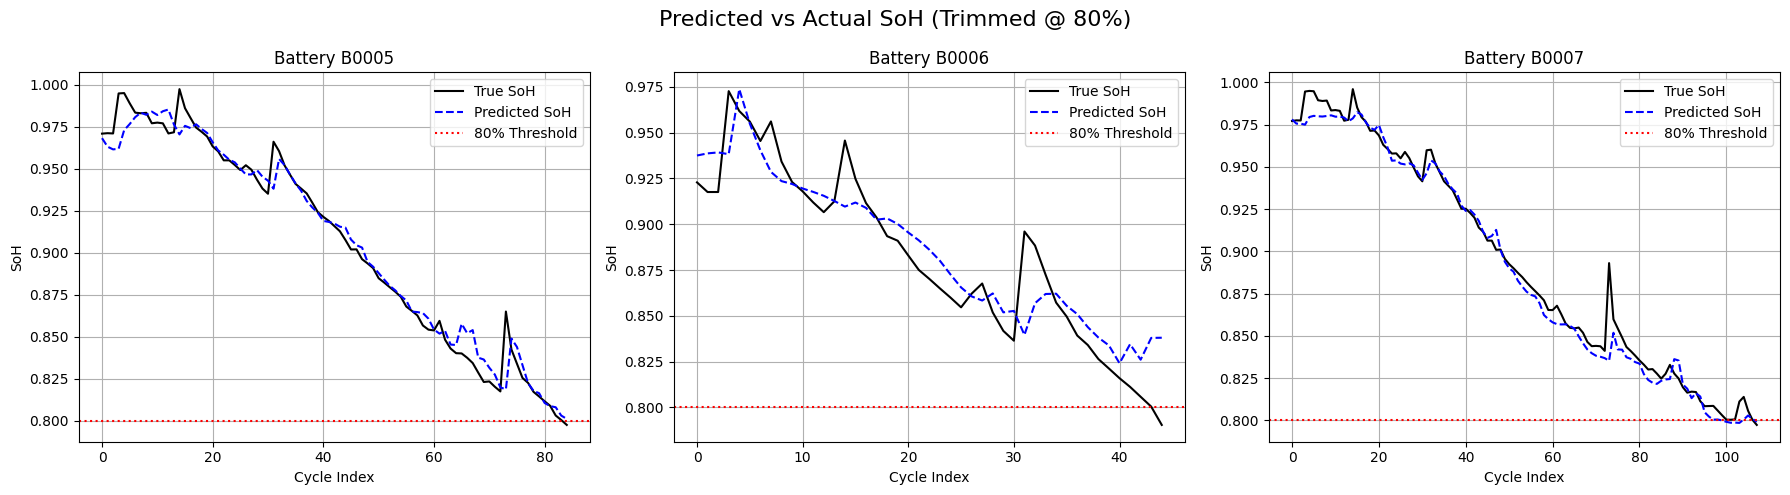

Battery B0005: MAE=0.0061, RMSE=0.0001, R2=0.9742
Battery B0006: MAE=0.0147, RMSE=0.0004, R2=0.8346
Battery B0007: MAE=0.0052, RMSE=0.0001, R2=0.9834

=== Threshold 0.85 ===


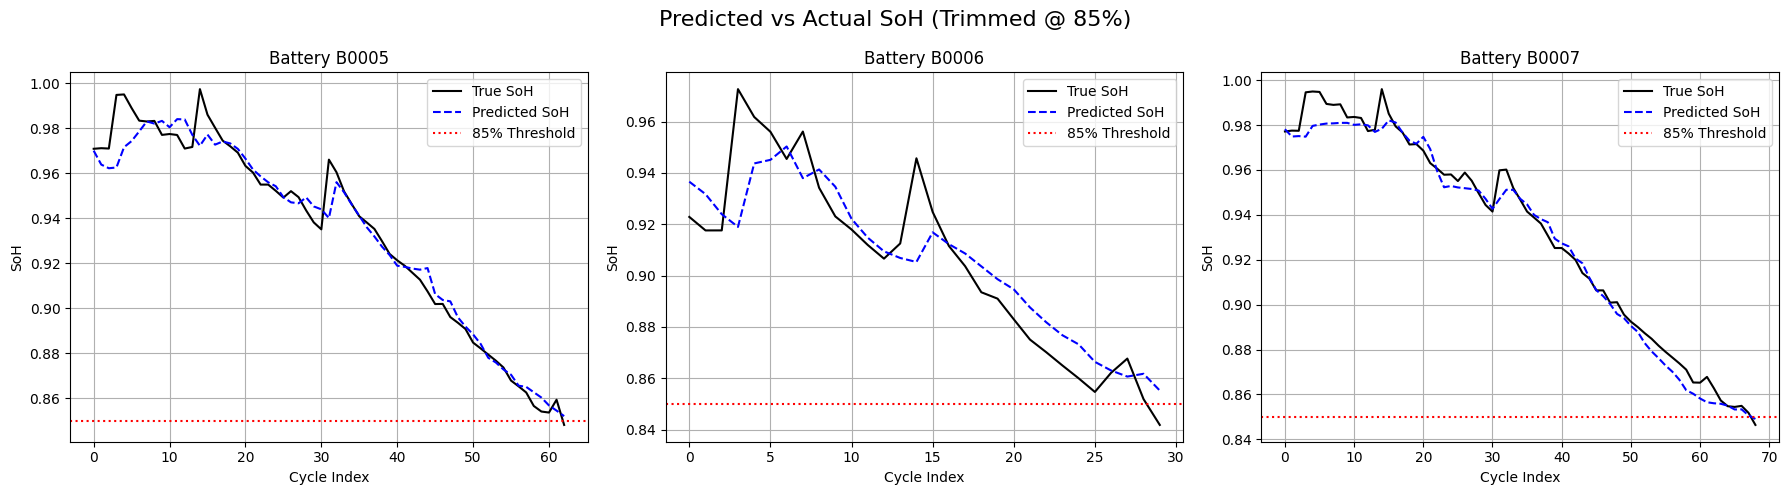

Battery B0005: MAE=0.0052, RMSE=0.0001, R2=0.9636
Battery B0006: MAE=0.0117, RMSE=0.0002, R2=0.8038
Battery B0007: MAE=0.0044, RMSE=0.0000, R2=0.9824


In [ ]:


def trim_to_EOL(df_in, threshold):
    """Trim each battery's data until first SoH crossing below threshold."""
    dfs = []
    for batt in df_in['battery_id'].unique():
        batt_df = df_in[df_in['battery_id'] == batt].reset_index(drop=True)
        below = batt_df[batt_df['SoH'] < threshold]
        if not below.empty:
            eol_idx = below.index[0]
            dfs.append(batt_df.iloc[:eol_idx + 1].copy())
    return pd.concat(dfs, ignore_index=True)

def create_sequences(df_in, seq_len=16):
    """Create sliding-window sequences of SoH for each battery."""
    battery_sequences = {}
    for batt in df_in['battery_id'].unique():
        batt_df = df_in[df_in['battery_id'] == batt].reset_index(drop=True)
        soh_series = batt_df['SoH'].values
        X, y = [], []
        for i in range(len(soh_series) - seq_len):
            X.append(soh_series[i:i+seq_len])
            y.append(soh_series[i+seq_len])
        if X:  # only if we have enough points
            battery_sequences[batt] = (np.array(X), np.array(y))
    return battery_sequences

def train_loocv(battery_sequences):
    """Leave-one-battery-out cross validation with RandomForestRegressor."""
    fold_results, battery_preds = [], {}
    for test_batt in battery_sequences:
        X_train, y_train = [], []
        for batt in battery_sequences:
            if batt != test_batt:
                Xb, yb = battery_sequences[batt]
                X_train.append(Xb)
                y_train.append(yb)
        X_train = np.vstack(X_train)
        y_train = np.concatenate(y_train)

        X_test, y_test = battery_sequences[test_batt]
        model = RandomForestRegressor(n_estimators=500, max_depth=30, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        battery_preds[test_batt] = (y_test, y_pred)
        fold_results.append({
            "battery": test_batt,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred)
        })
    return fold_results, battery_preds

def plot_results(battery_preds, threshold):
    cols = len(battery_preds)
    fig, axs = plt.subplots(1, cols, figsize=(6*cols, 5), squeeze=False)
    axs = axs[0]
    for idx, (batt, (y_true, y_pred)) in enumerate(battery_preds.items()):
        axs[idx].plot(y_true, label='True SoH', color='black')
        axs[idx].plot(y_pred, '--', label='Predicted SoH', color='blue')
        axs[idx].axhline(threshold, color='red', linestyle=':', label=f'{int(threshold*100)}% Threshold')
        axs[idx].set_title(f'Battery {batt}')
        axs[idx].set_xlabel('Cycle Index')
        axs[idx].set_ylabel('SoH')
        axs[idx].grid(True)
        axs[idx].legend()
    plt.suptitle(f'Predicted vs Actual SoH (Trimmed @ {int(threshold*100)}%)', fontsize=16)
    plt.tight_layout()
    plt.show()

# Run for multiple thresholds
thresholds = [0.70, 0.80, 0.85]
all_metrics = {}

for th in thresholds:
    print(f"\n=== Threshold {th:.2f} ===")
    df_trim = trim_to_EOL(df, threshold=th)
    seqs = create_sequences(df_trim, seq_len=16)
    if not seqs:
        print("No sequences generated for this threshold.")
        continue
    results, preds = train_loocv(seqs)
    all_metrics[th] = results
    plot_results(preds, th)
    for r in results:
        print(f"Battery {r['battery']}: MAE={r['MAE']:.4f}, RMSE={r['RMSE']:.4f}, R2={r['R2']:.4f}")


# Plots

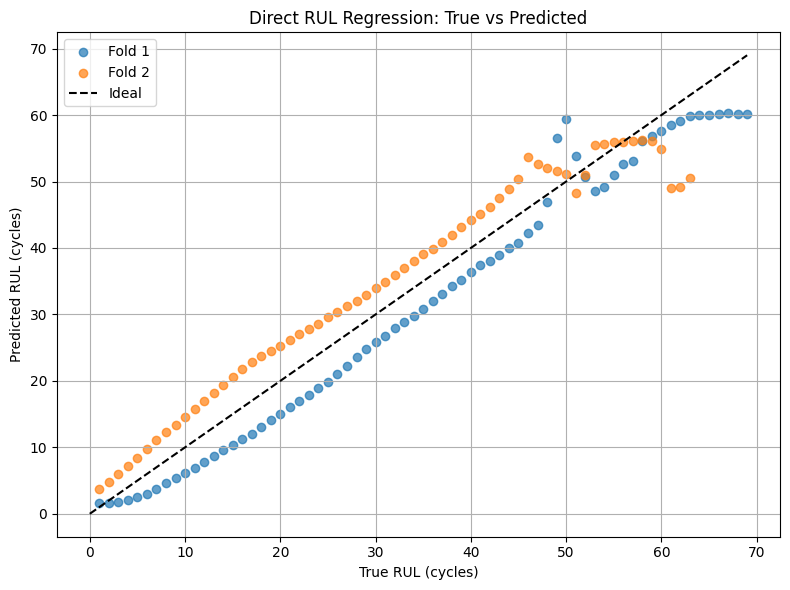

In [ ]:
# Predicted vs actual RUL (for direct RUL regression)
plt.figure(figsize=(8, 6))
for i, (train_idx, test_idx) in enumerate(cv.split(X_rul, y_rul, groups=groups)):
    model = RandomForestRegressor(n_estimators=500, max_depth=30, random_state=42)
    model.fit(X_rul[train_idx], y_rul[train_idx])
    y_pred = model.predict(X_rul[test_idx])
    plt.scatter(y_rul[test_idx], y_pred, label=f"Fold {i+1}", alpha=0.7)

plt.plot([0, max(y_rul)], [0, max(y_rul)], 'k--', label="Ideal")
plt.xlabel("True RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("Direct RUL Regression: True vs Predicted")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
